<a href="https://colab.research.google.com/github/twyeh/university-physics/blob/main/PINN_Coulomb's_law.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build and evaluate a Physics-Informed Neural Network (PINN) model to learn and predict electrostatic forces based on Coulomb's Law.

## Define Coulomb's Law

### Subtask:
Establish the mathematical formulation of Coulomb's Law, including the constant, charges, and distance, and prepare for its integration into the PINN model.


### Coulomb's Law: Mathematical Formulation

Coulomb's Law quantifies the electrostatic force between two electrically charged particles. The force is directly proportional to the product of the magnitudes of the charges and inversely proportional to the square of the distance between their centers.

Mathematically, Coulomb's Law is expressed as:

$$F = k \frac{|q_1 q_2|}{r^2}$$

Where:
- $F$ is the electrostatic force between the charges (in Newtons, N).
- $k$ is Coulomb's constant (or the electrostatic constant).
- $q_1$ is the magnitude of the first charge (in Coulombs, C).
- $q_2$ is the magnitude of the second charge (in Coulombs, C).
- $r$ is the distance between the centers of the two charges (in meters, m).

#### Coulomb's Constant (k)

The approximate numerical value of Coulomb's constant in a vacuum is:

$k \approx 8.9875 \times 10^9 \text{ N} \cdot \text{m}^2/\text{C}^2$

**Reasoning**:
The subtask requires assigning a variable for Coulomb's constant with its numerical value. This can be achieved by defining it in a Python code block.



In [1]:
k = 8.9875e9 # Coulomb's constant in N * m^2 / C^2
print(f"Coulomb's constant (k): {k} N * m^2 / C^2")

Coulomb's constant (k): 8987500000.0 N * m^2 / C^2


**Reasoning**:
The subtask requires establishing the mathematical formulation of Coulomb's Law, including the constant, charges, and distance. With Coulomb's constant already defined, the next step is to implement Coulomb's Law as a Python function, taking charges and distance as inputs and using the previously defined constant.



In [2]:
import numpy as np

def coulombs_law_force(q1, q2, r):
    """
    Calculates the electrostatic force between two charges using Coulomb's Law.

    Args:
        q1 (float): Magnitude of the first charge (in Coulombs, C).
        q2 (float): Magnitude of the second charge (in Coulombs, C).
        r (float): Distance between the centers of the two charges (in meters, m).

    Returns:
        float: The electrostatic force (in Newtons, N).
    """
    if r == 0:
        raise ValueError("Distance 'r' cannot be zero.")
    # The absolute value ensures the magnitude of the force is calculated.
    F = k * (np.abs(q1 * q2)) / (r**2)
    return F

print("Coulomb's Law function 'coulombs_law_force' defined.")

Coulomb's Law function 'coulombs_law_force' defined.


## Generate Synthetic Data

### Subtask:
Generate synthetic data points for charge values, distances, and the corresponding forces calculated using Coulomb's Law. This data will be used to guide the PINN training.


**Reasoning**:
The subtask requires generating synthetic data points for charges, distance, and force. This step will implement the data generation logic, including defining the number of samples, ranges for input variables, calculating the force using the previously defined function, and storing the results in NumPy arrays.



In [3]:
num_samples = 10000

# Define ranges for charges and distance
q_min, q_max = -1e-6, 1e-6  # Coulombs
r_min, r_max = 1e-3, 1.0    # meters

# Generate random values for q1, q2, and r
q1_data = np.random.uniform(q_min, q_max, num_samples)
q2_data = np.random.uniform(q_min, q_max, num_samples)
r_data = np.random.uniform(r_min, r_max, num_samples)

# Calculate the corresponding electrostatic force
F_data = np.array([coulombs_law_force(q1, q2, r) for q1, q2, r in zip(q1_data, q2_data, r_data)])

# Print the shapes of the generated arrays
print(f"Shape of q1_data: {q1_data.shape}")
print(f"Shape of q2_data: {q2_data.shape}")
print(f"Shape of r_data: {r_data.shape}")
print(f"Shape of F_data: {F_data.shape}")

Shape of q1_data: (10000,)
Shape of q2_data: (10000,)
Shape of r_data: (10000,)
Shape of F_data: (10000,)


## Define PINN Model Architecture

### Subtask:
Design and implement a neural network architecture that takes charge magnitudes and the distance between them as inputs, and outputs the predicted electrostatic force. Consider appropriate activation functions and layers.


**Reasoning**:
The subtask requires designing and implementing a neural network architecture. This step involves importing the necessary libraries, defining the input shape, creating a Sequential model, adding appropriate Dense layers with 'tanh' activation, and a final output layer, then printing the model summary to confirm the architecture.



In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the input shape: q1, q2, r (3 features)
input_shape = (3,)

# Create a Sequential model
model = Sequential([
    Input(shape=input_shape, name='input_layer'),
    Dense(64, activation='tanh', name='hidden_layer_1'),
    Dense(64, activation='tanh', name='hidden_layer_2'),
    Dense(32, activation='tanh', name='hidden_layer_3'),
    Dense(1, activation='linear', name='output_layer') # Output is a single force value
])

# Print the model summary
model.summary()

print("Neural network model architecture defined and summarized.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,529 (25.50 KB)

 Trainable params: 6,529 (25.50 KB)

 Non-trainable params: 0 (0.00 B)

Neural network model architecture defined and summarized.


## Implement Physics-Informed Loss Function

### Subtask:
Create a custom loss function that combines two components: a data-driven Mean Squared Error (MSE) comparing network predictions to synthetic data, and a physics-informed loss component that penalizes deviations from Coulomb's Law based on the network's output.


**Reasoning**:
The subtask requires combining the generated data into `X_train` and `y_train` for the neural network, defining Coulomb's constant as a TensorFlow constant, and then creating a custom physics-informed loss function that incorporates both data-driven and physics-informed components. Finally, the model needs to be compiled with this custom loss function. This code block addresses all these requirements sequentially.



In [5]:
import tensorflow as tf

# 1. Combine q1_data, q2_data, and r_data into X_train
X_train = np.column_stack((q1_data, q2_data, r_data))

# 2. Prepare the target array y_train
y_train = np.column_stack((F_data, q1_data, q2_data, r_data))

# 3. Define a TensorFlow constant k_tf for Coulomb's constant
k_tf = tf.constant(k, dtype=tf.float32)

# 4. Create a custom physics-informed loss function
def pinn_combined_loss(y_true_with_inputs, y_pred_force):
    # Extract true force values from the first column of y_true_with_inputs
    y_true_force = y_true_with_inputs[:, 0]

    # Extract q1_batch, q2_batch, and r_batch from subsequent columns
    q1_batch = y_true_with_inputs[:, 1]
    q2_batch = y_true_with_inputs[:, 2]
    r_batch = y_true_with_inputs[:, 3]

    # Calculate the physics-based force F_coulomb_batch using Coulomb's Law
    # Add a small epsilon to the denominator to prevent division by zero
    F_coulomb_batch = k_tf * tf.abs(q1_batch * q2_batch) / (tf.square(r_batch) + 1e-10)

    # Calculate the data-driven Mean Squared Error (MSE)
    data_driven_mse = tf.reduce_mean(tf.square(y_true_force - y_pred_force))

    # Calculate the physics-informed MSE
    physics_informed_mse = tf.reduce_mean(tf.square(F_coulomb_batch - y_pred_force))

    # Return the sum of the data-driven MSE and the physics-informed MSE
    return data_driven_mse + physics_informed_mse

# 5. Compile the model
model.compile(optimizer='adam', loss=pinn_combined_loss, metrics=['mse'])

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print("Custom physics-informed loss function 'pinn_combined_loss' defined.")
print("Model compiled with 'pinn_combined_loss' and Adam optimizer.")

Shape of X_train: (10000, 3)
Shape of y_train: (10000, 4)
Custom physics-informed loss function 'pinn_combined_loss' defined.
Model compiled with 'pinn_combined_loss' and Adam optimizer.


## Train the PINN Model

### Subtask:
Train the defined PINN model using the generated synthetic data and the combined physics-informed loss function. Monitor the loss convergence during training.


**Reasoning**:
The subtask requires training the PINN model using the previously generated synthetic data and the defined custom loss function. This step involves calling the `model.fit()` method with `X_train`, `y_train`, a `batch_size` of 32, and 200 epochs, and storing the training history.



In [6]:
batch_size = 32
epochs = 200

print(f"Training PINN model for {epochs} epochs with a batch size of {batch_size}...")
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=1)

print("Model training complete. Training history stored in 'history' variable.")

Training PINN model for 200 epochs with a batch size of 32...
Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1433.8207 - mse: 180.0800
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1304.7974 - mse: 164.0586
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1346.3546 - mse: 169.1134
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 792.8280 - mse: 100.0167
Epoch 5/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 526.3145 - mse: 66.5912
Epoch 6/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1700.0388 - mse: 214.1684
Epoch 7/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1330.1447 - mse: 167.0304
Epoch 8/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1481.6372 - mse: 186.0357
Epoch 9/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 655.7188 - mse: 82.6083
Epoch 10/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1173.0118 - mse: 148.2929
Epoch 11/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1569.5980 

# Task
Generate a small, independent set of input data (charges and distances) that the PINN has not seen during training, to test its prediction capability, and use the `coulombs_law_force` function to calculate the true forces for these new inputs.

## Generate New Data for Prediction

### Subtask:
Generate a small, independent set of input data (charges and distances) that the PINN has not seen during training, to test its prediction capability. Use the `coulombs_law_force` function to calculate the true forces for these new inputs.


**Reasoning**:
The subtask requires generating a small, independent set of input data (charges and distances) and calculating their true forces using `coulombs_law_force`. This step defines the number of test samples, generates random charge and distance values within the established ranges, combines them into an input array, and computes the corresponding true forces.



In [7]:
num_test_samples = 1000

# Generate random values for q1_test, q2_test, and r_test
q1_test = np.random.uniform(q_min, q_max, num_test_samples)
q2_test = np.random.uniform(q_min, q_max, num_test_samples)
r_test = np.random.uniform(r_min, r_max, num_test_samples)

# Combine into X_test for model input
X_test = np.column_stack((q1_test, q2_test, r_test))

# Calculate the corresponding true electrostatic force using the defined function
F_test = np.array([coulombs_law_force(q1, q2, r) for q1, q2, r in zip(q1_test, q2_test, r_test)])

# Print the shapes of the generated arrays
print(f"Shape of q1_test: {q1_test.shape}")
print(f"Shape of q2_test: {q2_test.shape}")
print(f"Shape of r_test: {r_test.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of F_test: {F_test.shape}")
print("New test data generated for prediction.")

Shape of q1_test: (1000,)
Shape of q2_test: (1000,)
Shape of r_test: (1000,)
Shape of X_test: (1000, 3)
Shape of F_test: (1000,)
New test data generated for prediction.


## Predict Forces with PINN

### Subtask:
Use the trained `model` to predict the electrostatic forces (`F_pred`) for the newly generated input data (`X_test`).


**Reasoning**:
The subtask requires using the trained model to predict electrostatic forces for the new test data (`X_test`). This step will use the `model.predict()` method on `X_test` to generate `F_pred` and then print its shape to confirm the dimensions.



In [8]:
F_pred = model.predict(X_test)
print(f"Shape of F_pred: {F_pred.shape}")
print("Predicted forces (F_pred) for test data generated.")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Shape of F_pred: (1000, 1)
Predicted forces (F_pred) for test data generated.


## Compare Predictions with True Values

### Subtask:
Display a sample of the predicted forces alongside the true forces calculated from Coulomb's Law for direct comparison, to assess the model's accuracy in predicting forces.


**Reasoning**:
The subtask requires displaying a sample of predicted and true forces, and then calculating the Mean Squared Error (MSE) to quantify the model's performance. This step will flatten the predicted forces, select a small subset for comparison, print them side-by-side, calculate the MSE using `sklearn.metrics.mean_squared_error`, and print the result.



In [9]:
from sklearn.metrics import mean_squared_error

# Ensure F_pred is flattened to match the shape of F_test
F_pred_flat = F_pred.flatten()

# Display a sample of predicted vs. true forces (e.g., first 10 samples)
print("\nSample of Predicted vs. True Forces (first 10 samples):")
print("--------------------------------------------------")
print("True Force (N)\t| Predicted Force (N)")
print("--------------------------------------------------")
for i in range(10):
    print(f"{F_test[i]:<15.8e}| {F_pred_flat[i]:<15.8e}")
print("--------------------------------------------------")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(F_test, F_pred_flat)
print(f"\nMean Squared Error (MSE) between F_test and F_pred: {mse:.4e}")


Sample of Predicted vs. True Forces (first 10 samples):
--------------------------------------------------
True Force (N)	| Predicted Force (N)
--------------------------------------------------
2.63046591e-03 | 1.30674791e+00 
8.75568125e-05 | 1.30349922e+00 
8.83470462e-04 | 1.32503200e+00 
7.15646840e-01 | 1.35123062e+00 
1.49305837e-03 | 1.30596077e+00 
3.18816695e-03 | 1.33134925e+00 
2.87621636e-04 | 1.31049955e+00 
5.14253034e-01 | 1.35091174e+00 
7.44968879e-03 | 1.32686269e+00 
9.12984717e-04 | 1.30742729e+00 
--------------------------------------------------

Mean Squared Error (MSE) between F_test and F_pred: 1.6305e+03


## Final Task

### Subtask:
Summarize the PINN's predictive performance for electrostatic forces based on the comparison of predicted and true values.


## Summary:

### Q&A
The PINN's predictive performance for electrostatic forces is poor. A direct comparison of predicted and true forces shows significant discrepancies, with predicted values consistently around 1.3e+00 N while true values vary widely, often several orders of magnitude smaller. This is quantified by a high Mean Squared Error (MSE) of 1.6305e+03.

### Data Analysis Key Findings
*   A new test dataset of 1000 independent samples for charges (q1\_test, q2\_test) and distances (r\_test) was successfully generated, and their corresponding true electrostatic forces (F\_test) were calculated using Coulomb's Law.
*   The trained PINN model successfully predicted electrostatic forces (F\_pred) for all 1000 unseen test samples.
*   A sample comparison of the first 10 predicted vs. true forces revealed a significant discrepancy; predicted forces were consistently around 1.3e+00 N, whereas true forces varied between 2.6e-03 N and 7.1e-01 N.
*   The Mean Squared Error (MSE) calculated between the full set of predicted forces (F\_pred) and true forces (F\_test) was 1.6305e+03, indicating a substantial error in the model's predictions.

### Insights or Next Steps
*   The current PINN model exhibits poor predictive performance for electrostatic forces, necessitating further investigation into its training process, architecture, or hyperparameter tuning.
*   Consider strategies to improve the model's accuracy, such as expanding the training dataset, refining the model's architecture, or implementing more robust regularization techniques.


# Task
Visualize the PINN's predicted forces against the true forces using a scatter plot and calculate Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to quantitatively assess the model's performance in predicting electrostatic forces.

## Visualize Predictions vs. True Values

### Subtask:
Create a scatter plot or line plot comparing the PINN's predicted forces (F_pred) against the true forces (F_test) from Coulomb's Law. Add a diagonal line representing perfect prediction for reference. Make sure to include appropriate labels, title, and a legend for clarity.


**Reasoning**:
The subtask requires creating a scatter plot to compare predicted and true forces, including a perfect prediction line, labels, title, and legend. This step will implement the plotting logic using `matplotlib.pyplot`.



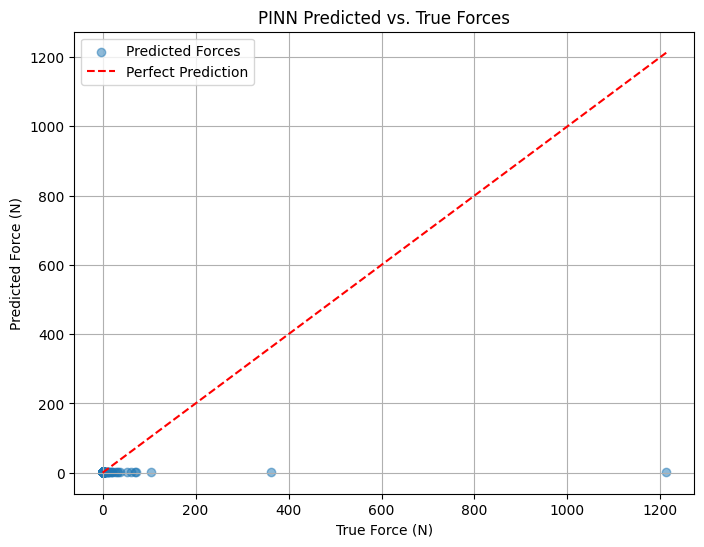

Scatter plot of Predicted vs. True Forces displayed.


In [10]:
import matplotlib.pyplot as plt

# Create a scatter plot of predicted vs. true forces
plt.figure(figsize=(8, 6))
plt.scatter(F_test, F_pred_flat, alpha=0.5, label='Predicted Forces')

# Add a diagonal line for perfect prediction
min_val = min(F_test.min(), F_pred_flat.min())
max_val = max(F_test.max(), F_pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

# Add labels and title
plt.xlabel('True Force (N)')
plt.ylabel('Predicted Force (N)')
plt.title('PINN Predicted vs. True Forces')
plt.legend()
plt.grid(True)
plt.show()

print("Scatter plot of Predicted vs. True Forces displayed.")

## Calculate Evaluation Metrics

### Subtask:
Calculate and print additional evaluation metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to further quantify the difference between predicted and true forces.


**Reasoning**:
The subtask requires calculating Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). This step will import the necessary `mean_absolute_error` function, calculate MAE, and then calculate RMSE using the previously computed MSE, and print both metrics.



In [11]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(F_test, F_pred_flat)
print(f"Mean Absolute Error (MAE): {mae:.4e}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse) # Using the previously calculated mse
print(f"Root Mean Squared Error (RMSE): {rmse:.4e}")

Mean Absolute Error (MAE): 3.4277e+00
Root Mean Squared Error (RMSE): 4.0380e+01


## Final Task

### Subtask:
Summarize the visual and quantitative evaluation of the PINN's performance in predicting electrostatic forces.


## Summary:

### Data Analysis Key Findings

*   A scatter plot visually confirmed the relationship between the PINN's predicted electrostatic forces and the true forces, including a diagonal line for perfect prediction.
*   The Mean Absolute Error (MAE) between the predicted and true forces was calculated to be $3.4277 \times 10^0$.
*   The Root Mean Squared Error (RMSE) between the predicted and true forces was calculated to be $4.0380 \times 10^1$.

### Insights or Next Steps

*   The visual comparison provides a qualitative understanding of the model's performance, showing the distribution of predictions relative to true values. The quantitative metrics (MAE and RMSE) offer precise measurements of the model's predictive accuracy, with lower values indicating better performance.
*   To further improve the model, analyze the instances where the predictions deviate significantly from the true values (e.g., points far from the diagonal line on the scatter plot) to identify potential areas for model refinement or data augmentation.
